In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

condition_colors = {
    'wiii8': '#be0f0a',
    'anosmic': '#e7533a',
    '9047': "#a71394",
    '23129': "#3318e3",
    '33300': "#cfee1e",
}


In [ ]:
"""
MUTANT VS ITS OWN PSEUDO POPULATION -- ROSEPLOT

Logic identical to FIGURE-1/ghXpseudo/vision_nearest-neighbour-roseplot-4.py:
  - speed normalised to each FILE's own mean speed at 10-20 mm from its nearest neighbour
  - restrict to closest_node_distance 1-5 mm, binned at 1.0 mm
  - one mean speed-vs-distance curve per file x angle bin, integrated with trapz -> one AUC per file
  - Mann-Whitney real vs pseudo per angle bin, BH-FDR corrected across the 6 bins
  - roseplot of |pseudo mean - real mean| with +/- sd_diff error bars and stars from p_corrected

One forced deviation from 4.py, because of what the sensory data actually contains:
  - pseudo is nearest_neighbour.feather, not .csv
Requires nearest_neighbour() to have been re-run on BOTH real and pseudo: the older outputs
on the volume carry `speed`/`acceleration`, not the `speed_body`/`speed_tail` split.
Conditions are loaded one at a time inside the loop rather than all concatenated up front,
because the pseudo sets are ~100 files each.
"""

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']

roseplot_conditions = ['wiii8', 'anosmic', '9047', '23129', '33300']


def auc_per_file(group):
    group = group.sort_values('bin_center')
    x = group['bin_center'].to_numpy(dtype=float)
    y = group['mean_speed_norm'].to_numpy(dtype=float)
    if len(x) < 2:
        return np.nan
    return np.trapz(y, x)


def roseplot_stats(condition):
    """One AUC per file x angle bin, then Mann-Whitney real vs pseudo, FDR corrected across bins."""
    nn_base = '/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory'
    columns = ['filename', 'speed_tail', 'closest_node_distance', 'approach_angle']
    angle_edges = np.arange(0, 181, 30)          # 0,30,60,90,120,150,180
    baseline_low, baseline_high = 10, 20         # far-field frames defining unaffected speed
    distance_edges = np.arange(1, 5.1, 1.0)      # 1-5 mm in 1 mm steps

    real = pd.read_csv(f'{nn_base}/{condition}/nearest_neighbour.csv', usecols=columns).assign(source='real')
    pseudo = pd.read_feather(f'{nn_base}/{condition}-pseudo/nearest_neighbour.feather', columns=columns).assign(source='pseudo')
    d = pd.concat([real, pseudo], ignore_index=True)

    ## ANGLE BINS
    d['approach_angle'] = pd.to_numeric(d['approach_angle'], errors='coerce')
    d['angle_bin'] = pd.cut(d['approach_angle'], angle_edges, include_lowest=True, right=False)
    d = d.dropna(subset=['angle_bin'])
    d['angle_bin'] = d['angle_bin'].astype(str)

    ## NORMALISE SPEED TO EACH FILE'S OWN 10-20 MM BASELINE
    baseline = (
        d.loc[d['closest_node_distance'].between(baseline_low, baseline_high, inclusive='both')]
         .groupby(['source', 'filename'])['speed_tail']
         .mean()
         .rename('mean_speed_10_20')
         .reset_index()
    )
    d = d.merge(baseline, on=['source', 'filename'], how='left')
    d = d.dropna(subset=['mean_speed_10_20']).copy()
    d['speed_norm'] = d['speed_tail'] / d['mean_speed_10_20']

    ## DISTANCE BINS 1-5 MM
    d = d[(d['closest_node_distance'] > 1) & (d['closest_node_distance'] <= 5)].copy()
    d['bin'] = pd.cut(d['closest_node_distance'], distance_edges, include_lowest=True, right=True)
    d['bin_center'] = d['bin'].apply(lambda x: x.mid).astype(float)

    ## ONE SPEED CURVE PER FILE, THEN ONE AUC PER FILE X ANGLE BIN
    replicates = (
        d.groupby(['source', 'filename', 'angle_bin', 'bin_center'], observed=True)['speed_norm']
         .mean()
         .reset_index(name='mean_speed_norm')
    )
    auc = (
        replicates.groupby(['source', 'filename', 'angle_bin'], observed=True)
                  .apply(auc_per_file)
                  .reset_index(name='auc')
                  .dropna(subset=['auc'])
    )
    print(auc.groupby(['angle_bin', 'source'])['auc'].count().unstack(fill_value=0))

    ## MANN-WHITNEY PER ANGLE BIN, FDR CORRECTED ACROSS BINS
    rows = []
    for angle_bin, sub in auc.groupby('angle_bin'):
        real_auc = sub.loc[sub['source'] == 'real', 'auc']
        pseudo_auc = sub.loc[sub['source'] == 'pseudo', 'auc']
        if real_auc.size == 0 or pseudo_auc.size == 0:
            continue

        u, p = mannwhitneyu(real_auc, pseudo_auc, alternative='two-sided')
        rows.append({
            'condition': condition,
            'angle_bin': angle_bin,
            'n_real': real_auc.size,
            'n_pseudo': pseudo_auc.size,
            'mean_real': real_auc.mean(),
            'mean_pseudo': pseudo_auc.mean(),
            'relative_area': pseudo_auc.mean() - real_auc.mean(),
            'sem_real': real_auc.sem(),
            'sem_pseudo': pseudo_auc.sem(),
            'sem_diff': np.sqrt(real_auc.sem()**2 + pseudo_auc.sem()**2),
            'sd_real': real_auc.std(),
            'sd_pseudo': pseudo_auc.std(),
            'sd_diff': np.sqrt(real_auc.std()**2 + pseudo_auc.std()**2),
            'u_stat': u,
            'p_raw': p,
        })

    results = pd.DataFrame(rows)
    passed, p_corr, _, _ = multipletests(results['p_raw'], alpha=0.05, method='fdr_bh')
    results['p_corrected'] = p_corr
    results['significant'] = passed
    return results


def pseudo_angle_center(label):
    left = float(label.split(',')[0].strip('[('))
    right = float(label.split(',')[1].strip(' )]'))
    return (left + right) / 2


def pseudo_star(p):
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return ''


def plot_pseudo_roseplot(results, condition):
    """Magnitude of the pseudo - real speed difference per angle bin, stars from the corrected p."""
    width = np.deg2rad(30)

    res = results.copy()
    res['angle_center_deg'] = res['angle_bin'].apply(pseudo_angle_center)
    res = res.sort_values('angle_center_deg')

    theta = np.deg2rad(res['angle_center_deg'].to_numpy())

    # magnitude of the effect (PSEUDO - REAL)
    r = np.abs(res['relative_area'].to_numpy())

    # error bars: +/- 1 SD of the difference between the two group means
    sd = res['sd_diff'].to_numpy()
    ci_low_plot = np.clip(r - sd, 0, None)
    ci_high_plot = r + sd

    fig = plt.figure(figsize=(7, 7))
    ax = plt.subplot(111, projection='polar')

    ax.bar(
        theta, r, width=width, align='center',
        color=condition_colors[condition], edgecolor='0.2', linewidth=1.5,
    )

    for th, low, high in zip(theta, ci_low_plot, ci_high_plot):
        ax.plot([th, th], [low, high], color='black', linewidth=2, solid_capstyle='round')

    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_thetamin(0)
    ax.set_thetamax(180)

    ax.set_yticklabels([])
    ax.yaxis.grid(False)
    ax.xaxis.grid(True, linewidth=1, alpha=0.8, color='0.3')
    ax.spines['polar'].set_linewidth(1)

    rmax = ci_high_plot.max() * 1.2
    ax.set_rlim(0, rmax)

    for th, high, p in zip(theta, ci_high_plot, res['p_corrected'].to_numpy()):
        label = pseudo_star(p)
        if label:
            ax.text(th, high + rmax * 0.05, label, ha='center', va='center', fontsize=18, fontweight='bold')

    ax.set_frame_on(False)
    ax.set_xticks(np.deg2rad([0, 30, 60, 90, 120, 150, 180]))
    ax.set_xticklabels(['0°', '30°', '60°', '90°', '120°', '150°', '180°'])
    ax.set_title(f'Speed Difference: {condition} vs pseudo', pad=20)

    plt.tight_layout()
    plt.show()

===== wiii8 vs pseudo =====
source      pseudo  real
angle_bin               
[0, 30)        100    10
[120, 150)     100    10
[150, 180)     100    10
[30, 60)       100    10
[60, 90)       100    10
[90, 120)      100    10
condition  angle_bin  n_real  n_pseudo  mean_real  mean_pseudo  relative_area  sem_real  sem_pseudo  sem_diff  sd_real  sd_pseudo  sd_diff  u_stat    p_raw  p_corrected  significant
    wiii8    [0, 30)      10       100   2.930312     2.830897      -0.099415  0.123849    0.031097  0.127693 0.391644   0.310971 0.500088   619.0 0.217910     0.653730        False
    wiii8 [120, 150)      10       100   2.861416     2.833745      -0.027671  0.049716    0.024306  0.055340 0.157216   0.243064 0.289477   572.0 0.457226     0.763382        False
    wiii8 [150, 180)      10       100   2.974665     2.867263      -0.107402  0.121689    0.026159  0.124469 0.384815   0.261588 0.465308   640.0 0.146933     0.653730        False
    wiii8   [30, 60)      10       100   2.8

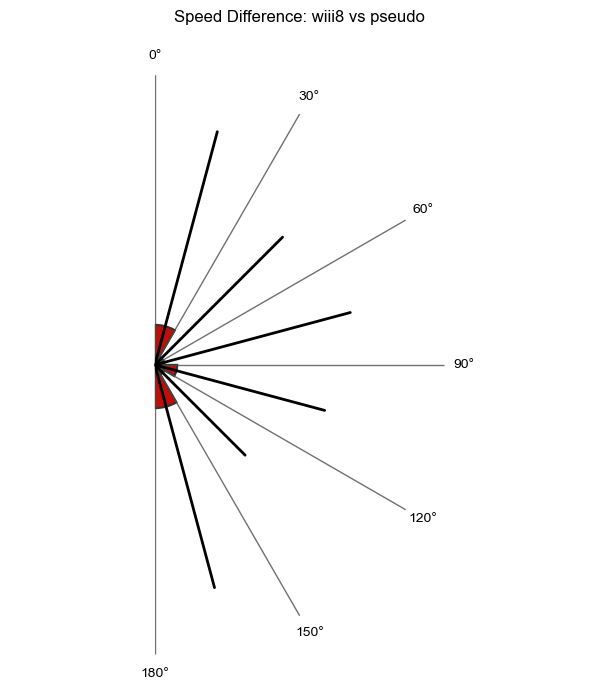

===== anosmic vs pseudo =====
source      pseudo  real
angle_bin               
[0, 30)        100    10
[120, 150)     100    10
[150, 180)     100    10
[30, 60)       100    10
[60, 90)       100    10
[90, 120)      100    10
condition  angle_bin  n_real  n_pseudo  mean_real  mean_pseudo  relative_area  sem_real  sem_pseudo  sem_diff  sd_real  sd_pseudo  sd_diff  u_stat    p_raw  p_corrected  significant
  anosmic    [0, 30)      10       100   2.779227     2.916529       0.137302  0.098315    0.021421  0.100621 0.310898   0.214211 0.377550   399.0 0.296046     0.544406        False
  anosmic [120, 150)      10       100   2.736228     2.848289       0.112061  0.089233    0.016893  0.090818 0.282179   0.168933 0.328882   395.0 0.277240     0.544406        False
  anosmic [150, 180)      10       100   2.827002     2.924086       0.097084  0.085342    0.016917  0.087002 0.269874   0.169170 0.318513   430.0 0.469909     0.563891        False
  anosmic   [30, 60)      10       100   2

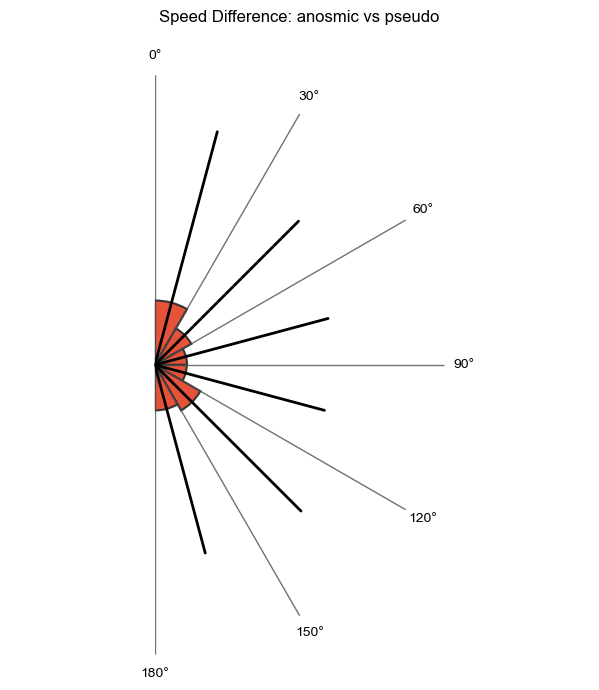

===== 9047 vs pseudo =====
source      pseudo  real
angle_bin               
[0, 30)        100    10
[120, 150)     100    10
[150, 180)     100    10
[30, 60)       100    10
[60, 90)       100    10
[90, 120)      100    10
condition  angle_bin  n_real  n_pseudo  mean_real  mean_pseudo  relative_area  sem_real  sem_pseudo  sem_diff  sd_real  sd_pseudo  sd_diff  u_stat    p_raw  p_corrected  significant
     9047    [0, 30)      10       100   2.743157     2.891255       0.148098  0.085807    0.026408  0.089779 0.271345   0.264083 0.378640   342.0 0.101504     0.298665        False
     9047 [120, 150)      10       100   2.649321     2.796570       0.147249  0.088257    0.023379  0.091301 0.279095   0.233789 0.364076   367.0 0.168305     0.298665        False
     9047 [150, 180)      10       100   2.765031     2.815457       0.050427  0.113627    0.019232  0.115243 0.359321   0.192322 0.407553   482.0 0.855617     0.855617        False
     9047   [30, 60)      10       100   2.75

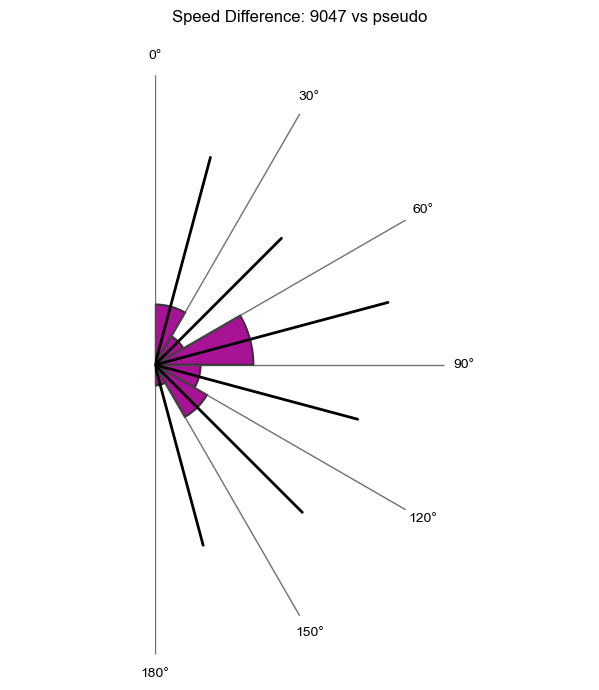

===== 23129 vs pseudo =====
source      pseudo  real
angle_bin               
[0, 30)        100    10
[120, 150)     100    10
[150, 180)     100    10
[30, 60)       100    10
[60, 90)       100    10
[90, 120)      100    10
condition  angle_bin  n_real  n_pseudo  mean_real  mean_pseudo  relative_area  sem_real  sem_pseudo  sem_diff  sd_real  sd_pseudo  sd_diff  u_stat    p_raw  p_corrected  significant
    23129    [0, 30)      10       100   2.714675     2.873739       0.159063  0.090607    0.025112  0.094022 0.286523   0.251124 0.380997   330.0 0.078006     0.345616        False
    23129 [120, 150)      10       100   2.875051     2.905615       0.030564  0.072303    0.021163  0.075336 0.228641   0.211634 0.311554   443.0 0.556895     0.668275        False
    23129 [150, 180)      10       100   2.955934     2.936548      -0.019386  0.054301    0.020135  0.057914 0.171716   0.201355 0.264632   521.0 0.831211     0.831211        False
    23129   [30, 60)      10       100   2.8

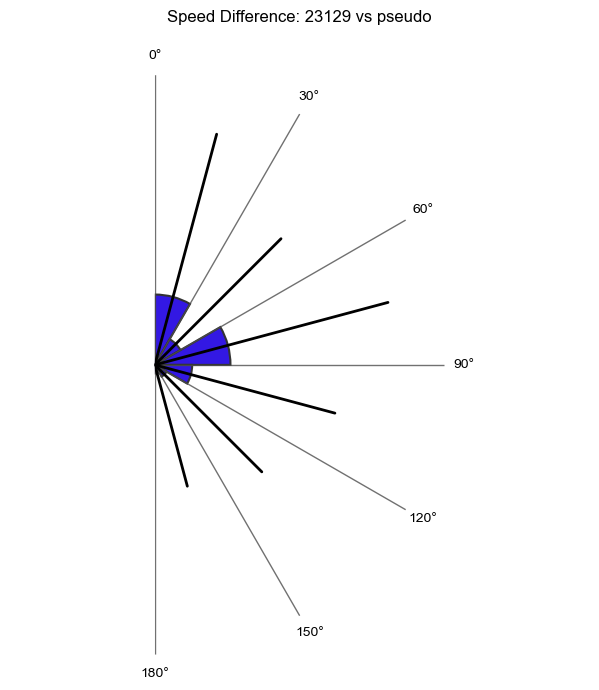

===== 33300 vs pseudo =====
source      pseudo  real
angle_bin               
[0, 30)        100     1
[120, 150)     100     1
[150, 180)     100     1
[30, 60)       100     1
[60, 90)       100     1
[90, 120)      100     1
condition  angle_bin  n_real  n_pseudo  mean_real  mean_pseudo  relative_area  sem_real  sem_pseudo  sem_diff  sd_real  sd_pseudo  sd_diff  u_stat    p_raw  p_corrected  significant
    33300    [0, 30)       1       100   3.316010     3.004634      -0.311376       NaN    0.040769       NaN      NaN   0.407685      NaN    77.0 0.475248     0.831683        False
    33300 [120, 150)       1       100   3.096333     2.936010      -0.160323       NaN    0.033566       NaN      NaN   0.335656      NaN    70.0 0.613861     0.831683        False
    33300 [150, 180)       1       100   2.929816     2.957301       0.027484       NaN    0.033284       NaN      NaN   0.332842      NaN    55.0 0.910891     0.910891        False
    33300   [30, 60)       1       100   2.7

ValueError: Axis limits cannot be NaN or Inf

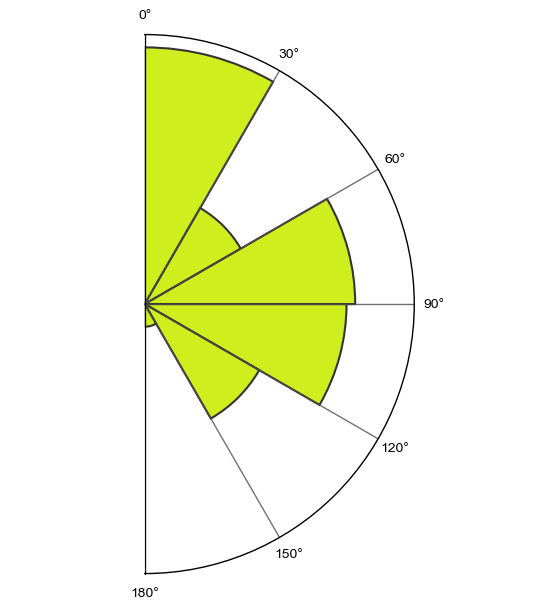

In [3]:
# One roseplot per condition, each against its own pseudo population.
roseplot_results = {}

for condition in roseplot_conditions:
    print(f'===== {condition} vs pseudo =====')
    results = roseplot_stats(condition)
    roseplot_results[condition] = results
    print(results.to_string(index=False))
    plot_pseudo_roseplot(results, condition)